# Exploratory Data Analysis

Before building any machine learning model, it is essential to understand the dataset. Exploratory Data Analysis (EDA) helps us inspect the available features, identify data quality issues, understand the distribution of the variables, and investigate which passenger characteristics appear to be associated with survival.

In this notebook we will:

* Load the training and test datasets.
* Inspect their structure and contents.
* Examine missing values and data types.
* Explore the distribution of the target variable.
* Analyze the relationship between passenger attributes and survival.
* Identify potential opportunities for feature engineering in the next stage.

By the end of this notebook, we should have a solid understanding of the data and a clear plan for preparing it for machine learning models.


## Dataset Description

The training dataset contains one row per passenger and the following variables:

| Feature    | Description                                                                                                                                    |
| ---------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| `Survived` | Target variable. `0` indicates the passenger did not survive, while `1` indicates survival. This column is only available in the training set. |
| `Pclass`   | Passenger ticket class (`1` = First, `2` = Second, `3` = Third).                                                                               |
| `Name`     | Passenger's full name.                                                                                                                         |
| `Sex`      | Passenger's sex (`male` or `female`).                                                                                                          |
| `Age`      | Passenger's age in years. Fractional values represent infants, while values ending in `.5` correspond to estimated ages.                       |
| `SibSp`    | Number of siblings and spouses aboard the Titanic.                                                                                             |
| `Parch`    | Number of parents and children aboard the Titanic. Children traveling only with a nanny have `Parch = 0`.                                      |
| `Ticket`   | Ticket number.                                                                                                                                 |
| `Fare`     | Passenger fare.                                                                                                                                |
| `Cabin`    | Cabin identifier. Many values are missing.                                                                                                     |
| `Embarked` | Port of embarkation (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton).                                                                    |

The `SibSp` and `Parch` variables deserve a brief clarification. In the context of this dataset:

* `Sibling` includes brother, sister, stepbrother, and stepsister.
* `Spouse` includes husband and wife (fiancés and mistresses are not considered).
* `Parent` includes mother and father.
* `Child` includes daughter, son, stepdaughter, and stepson.

## Imports

First, we import the libraries used throughout the analysis.

In [27]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## Loading the Data

The dataset is split into a training set and a test set. The training data includes the target variable (`Survived`), which we aim to predict, while the test set contains only the input features and is used for final Kaggle submission.

We begin by loading both datasets and performing an initial inspection. This includes checking dataset dimensions, verifying consistency of feature names across train and test sets, and looking for potential issues such as duplicated rows or obvious structural inconsistencies.

In [28]:
df_test = pd.read_csv("data/test.csv")
df_train = pd.read_csv("data/train.csv")

print(
f"""
--------------------
Train set:

{df_train.shape[0]} rows
{df_train.duplicated().sum()} duplicated rows
{df_train.shape[1]} columns
--------------------
Test set:

{df_test.shape[0]} rows
{df_test.duplicated().sum()} duplicated rows
{df_test.shape[1]} columns
--------------------
Columns train/test:
{[column for column in df_train.columns if column in df_test.columns]}

Target variable (only in test):
{[column for column in df_train.columns if column not in df_test.columns]}
--------------------
"""
)


--------------------
Train set:

891 rows
0 duplicated rows
12 columns
--------------------
Test set:

418 rows
0 duplicated rows
11 columns
--------------------
Columns train/test:
['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Target variable (only in test):
['Survived']
--------------------



In [29]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [31]:
# All features minus the tareget
features = [column for column in df_test.columns if column not in ("PassengerId", "Survived")]

# feature description dataframe
df_features = pd.DataFrame({
    "Name": features,
    "Type": ["numerical" if pd.api.types.is_numeric_dtype(df_test[column]) else "categorical" for column in features],
    "Category":["original"]*len(features),
    "Source":features,
})

feature_to_description = {
    "Survived": "Target variable. `0` indicates the passenger did not survive, while `1` indicates survival. This column is only available in the training set.",
    "Pclass": "Passenger ticket class (`1` = First, `2` = Second, `3` = Third).",
    "Name": "Passenger's full name.",
    "Sex": "Passenger's sex (`male` or `female`).",
    "Age": "Passenger's age in years. Fractional values represent infants, while values ending in `.5` correspond to estimated ages.",
    "SibSp": "Number of siblings and spouses aboard the Titanic.",
    "Parch": "Number of parents and children aboard the Titanic. Children traveling only with a nanny have `Parch = 0`.",
    "Ticket": "Ticket number.",
    "Fare": "Passenger fare.",
    "Cabin": "Cabin identifier. Many values are missing.",
    "Embarked": "Port of embarkation (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton).",
}

df_features["Description"] = df_features["Name"].map(feature_to_description)

df_features

,Name,Type,Category,Source,Description
0,Pclass,numerical,original,Pclass,"Passenger ticket class (`1` = First, `2` = Sec..."
1,Name,categorical,original,Name,Passenger's full name.
2,Sex,categorical,original,Sex,Passenger's sex (`male` or `female`).
3,Age,numerical,original,Age,Passenger's age in years. Fractional values re...
4,SibSp,numerical,original,SibSp,Number of siblings and spouses aboard the Tita...
5,Parch,numerical,original,Parch,Number of parents and children aboard the Tita...
6,Ticket,categorical,original,Ticket,Ticket number.
7,Fare,numerical,original,Fare,Passenger fare.
8,Cabin,categorical,original,Cabin,Cabin identifier. Many values are missing.
9,Embarked,categorical,original,Embarked,"Port of embarkation (`C` = Cherbourg, `Q` = Qu..."


In [32]:
# Train/Test split
df_train["IsTrainSet"] = True
df_test["IsTrainSet"] = False

df_full = pd.concat(
    [df_train, df_test],
    axis=0,
    ignore_index=True
)

print(
    f"""
    Full dataset ( train + test ):

    {df_full.shape[0]} rows
    {df_full.duplicated().sum()} duplicated rows
    {df_full.shape[1]} columns
    """
)

df_full


    Full dataset ( train + test ):

    1309 rows
    0 duplicated rows
    13 columns
    


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,IsTrainSet
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,True
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,True
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,False
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,False
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,False
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,False


In order to start getting a feel for the data we have in our hands, we can use `info()` and `describe()` to learn about data types, missing data, and overall statistical metrics such as mean, median, max, min etc.

In [33]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
 12  IsTrainSet   1309 non-null   bool   
dtypes: bool(1), float64(3), int64(4), object(5)
memory usage: 124.1+ KB


In [34]:
df_full.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


## Missing values

I always like to visually inspect how much of the data is missing before proceeding with the analysis.

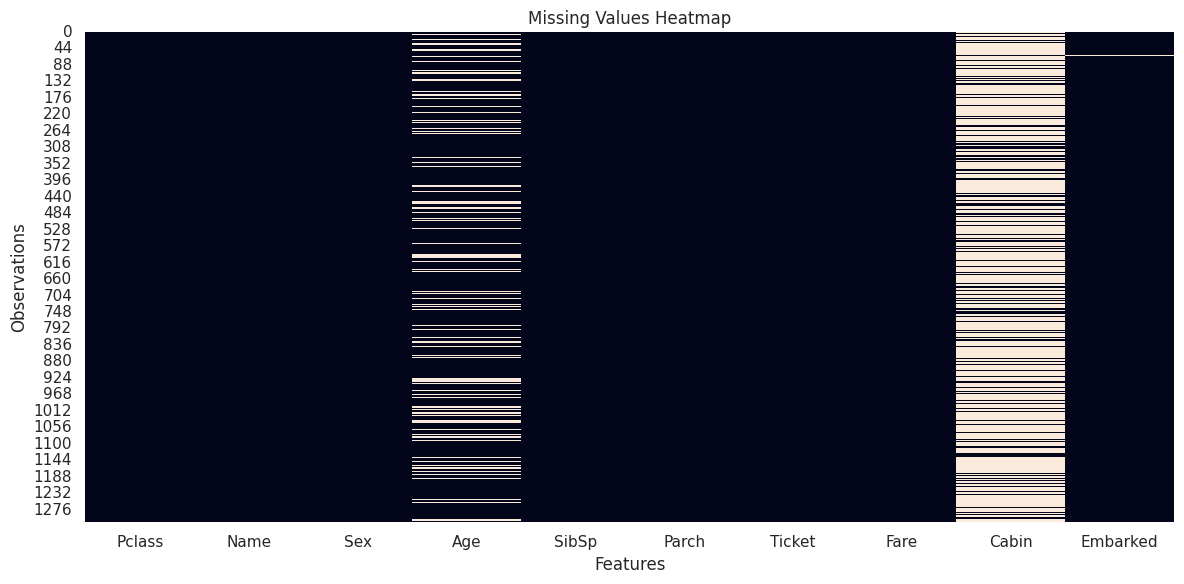

In [35]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df_full[features].isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Observations")

plt.tight_layout()
plt.show()

The heatmap above shows that the dataset contains relatively few missing values. Most features are complete, with only three columns requiring attention:

* `Cabin` has a large proportion of missing values. Because most entries are unavailable, we will exclude this feature from our analysis.
* `Embarked` has only a few missing values, which will be filled with the most frequent port of embarkation.
* `Age` contains a moderate number of missing values. Since age is likely to be an informative predictor of survival, we will impute the missing values rather than discard the affected rows. Before deciding on an imputation strategy, we will examine how the median age varies across different groups of passengers to determine whether a global median or a group-specific median is more appropriate.

### Choosing an Imputation Strategy for `Age`

A common baseline approach is to replace missing values with the global median age. However, passengers on the Titanic were not a homogeneous population. For example, age distributions may differ between passenger classes or between males and females. If these differences are substantial, using a single global median could introduce unnecessary bias.

To investigate this, we compare the median age computed:

* Across the entire dataset.
* Grouped by `Sex`.
* Grouped by `Pclass`.
* Grouped by both `Sex` and `Pclass`.

This comparison will help us determine whether a more granular imputation strategy is justified.

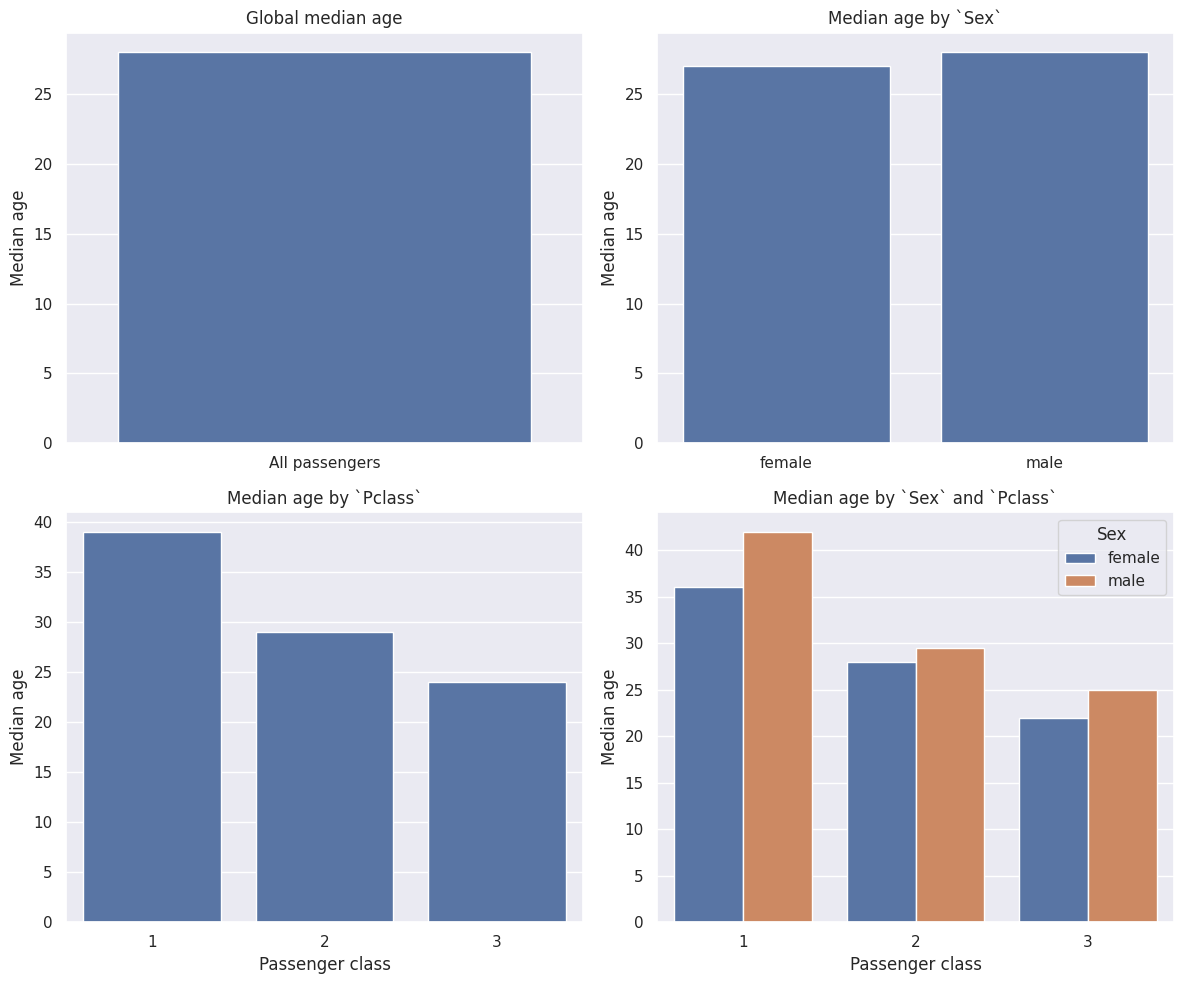

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Global median
global_median = df_full["Age"].median()

sns.barplot(
    x=["All passengers"],
    y=[global_median],
    ax=axes[0, 0]
)

axes[0, 0].set_title("Global median age")
axes[0, 0].set_ylabel("Median age")
axes[0, 0].set_xlabel("")

# Median by Sex
median_by_sex = (
    df_full
    .groupby("Sex")["Age"]
    .median()
    .reset_index()
)

sns.barplot(
    data=median_by_sex,
    x="Sex",
    y="Age",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Median age by `Sex`")
axes[0, 1].set_ylabel("Median age")
axes[0, 1].set_xlabel("")

# Median by Pclass
median_by_class = (
    df_full
    .groupby("Pclass")["Age"]
    .median()
    .reset_index()
)

sns.barplot(
    data=median_by_class,
    x="Pclass",
    y="Age",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Median age by `Pclass`")
axes[1, 0].set_ylabel("Median age")
axes[1, 0].set_xlabel("Passenger class")

# Median by Sex and Pclass
median_by_group = (
    df_full
    .groupby(["Pclass", "Sex"])["Age"]
    .median()
    .reset_index()
)

sns.barplot(
    data=median_by_group,
    x="Pclass",
    y="Age",
    hue="Sex",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Median age by `Sex` and `Pclass`")
axes[1, 1].set_ylabel("Median age")
axes[1, 1].set_xlabel("Passenger class")

plt.tight_layout()
plt.show()

The plots above show that the median age varies considerably across passenger classes and, to a lesser extent, between males and females. While a single global median would provide a simple baseline, it would ignore these differences and assign the same age to passengers from groups with noticeably different age distributions.

Based on this analysis, we chose to impute missing values in `Age` using the median age computed within each (`Pclass`, `Sex`) group. This approach preserves more of the underlying structure of the data while remaining simple, interpretable, and computationally inexpensive.

In [37]:
df_full["Age"] = (
    df_full.groupby(["Pclass", "Sex"])["Age"]
           .transform(lambda s: s.fillna(s.median()))
)

### Fill missing values in `Embarked` with the mode

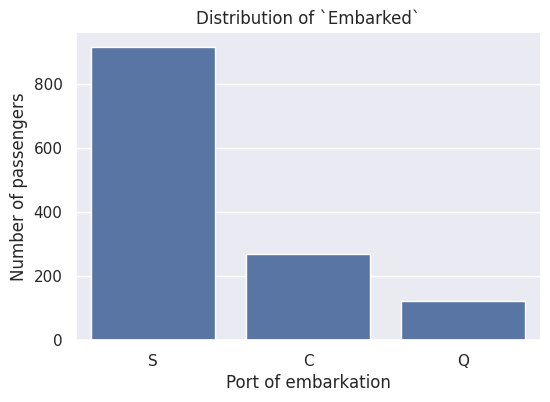

In [38]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_full,
    x="Embarked",
    order=df_full["Embarked"].value_counts().index
)

plt.title("Distribution of `Embarked`")
plt.xlabel("Port of embarkation")
plt.ylabel("Number of passengers")

plt.show()

The figure above shows that most passengers embarked at **Southampton (`S`)**, making it the mode of the `Embarked` feature by a large margin. Since only a few values are missing, replacing them with the most frequent category is a simple and reasonable imputation strategy that is unlikely to affect the overall distribution of the data.

In [39]:
# Fill missing values in `Embarked` with the most frequent category
embarked_mode = df_full["Embarked"].mode()[0]
df_full["Embarked"] = df_full["Embarked"].fillna(embarked_mode)

### Removing `Cabin`

The `Cabin` feature contains missing values for the majority of passengers. While it is possible to extract potentially useful information from the cabin identifier (such as the deck), the large proportion of missing entries would require more sophisticated imputation or feature engineering techniques.

For this tutorial, we choose to remove `Cabin` from the analysis and focus on features that are more complete and straightforward to preprocess. This simplifies the modeling pipeline while retaining the variables that carry most of the predictive information.

In [40]:
# Remove the `Cabin` column from the datasets
for df in [df_full, df_train, df_test]:
    if "Cabin" in df.columns:
        df.drop(columns="Cabin", inplace=True)

# Remove the `Cabin` row from the feature description table
df_features = df_features[df_features["Name"] != "Cabin"].reset_index(drop=True)

# Remove `Cabin` from the feature list
if "Cabin" in features:
    features.remove("Cabin")

df_features

,Name,Type,Category,Source,Description
0,Pclass,numerical,original,Pclass,"Passenger ticket class (`1` = First, `2` = Sec..."
1,Name,categorical,original,Name,Passenger's full name.
2,Sex,categorical,original,Sex,Passenger's sex (`male` or `female`).
3,Age,numerical,original,Age,Passenger's age in years. Fractional values re...
4,SibSp,numerical,original,SibSp,Number of siblings and spouses aboard the Tita...
5,Parch,numerical,original,Parch,Number of parents and children aboard the Tita...
6,Ticket,categorical,original,Ticket,Ticket number.
7,Fare,numerical,original,Fare,Passenger fare.
8,Embarked,categorical,original,Embarked,"Port of embarkation (`C` = Cherbourg, `Q` = Qu..."


## Relationship Between Features and Survival

After handling the missing values, we can begin exploring how each feature relates to the target variable, `Survived`. The goal of this analysis is not to establish causal relationships, but rather to identify patterns that may help a classification model distinguish between passengers who survived and those who did not.

Throughout this section, we examine the distribution of survival across the available features and highlight variables that appear to carry predictive information. These observations will also guide the feature engineering and model development stages of the project.


### `Sex`

One of the first questions we can ask is whether passenger sex was associated with survival. Since `Sex` is a categorical variable, a simple comparison of survival rates between males and females provides an intuitive way to assess its predictive power.

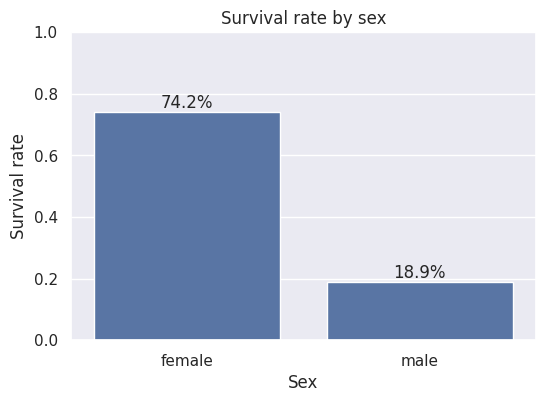

In [41]:
survival_by_sex = (
    df_train
    .groupby("Sex")["Survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=survival_by_sex,
    x="Sex",
    y="Survived"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )


plt.title("Survival rate by sex")
plt.xlabel("Sex")
plt.ylabel("Survival rate")

plt.ylim(0, 1)

plt.show()


The figure above shows a striking difference in survival rates between male and female passengers. While only a small fraction of males survived, the majority of females did.

This pattern reflects the historical evacuation policy commonly described as *"women and children first"*, which prioritized women during the lifeboat evacuation. From a machine learning perspective, the result indicates that `Sex` is likely to be one of the most informative predictors of passenger survival and should therefore be retained as an important feature in our classification models.

### `Age`

Age may have played an important role in survival, particularly given the historical accounts of evacuation procedures prioritizing women and children. Here, we investigate the relationship between passenger age and survival to determine whether age provides useful predictive information.

To explore this relationship, we compare the age distributions of passengers who survived with those who did not. Displaying the two distributions side by side allows us to identify differences in their overall shape while avoiding the visual clutter that can arise from overlapping histograms.

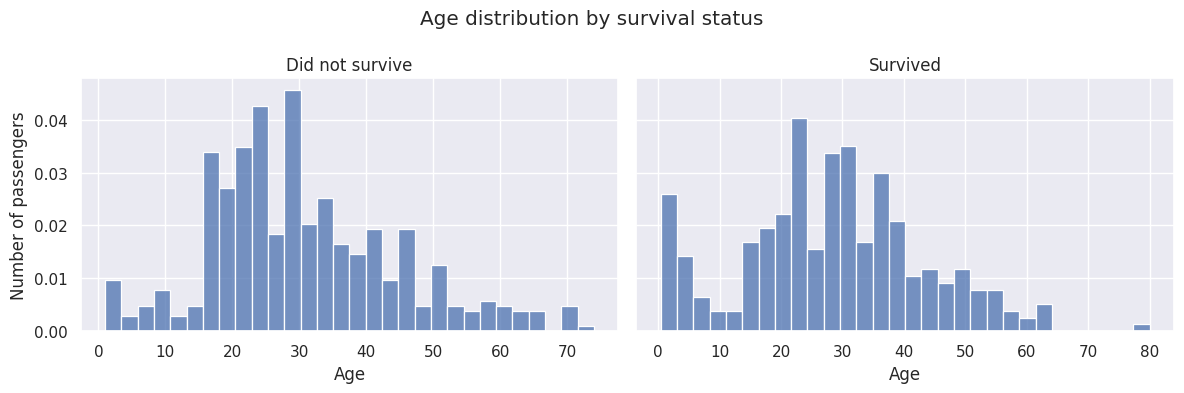

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Passengers who did not survive
sns.histplot(
    data=df_train[df_train["Survived"] == 0],
    stat="density",
    x="Age",
    bins=30,
    ax=axes[0]
)

axes[0].set_title("Did not survive")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of passengers")

# Passengers who survived
sns.histplot(
    data=df_train[df_train["Survived"] == 1],
    stat="density",
    x="Age",
    bins=30,
    ax=axes[1]
)

axes[1].set_title("Survived")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("")

plt.suptitle("Age distribution by survival status")
plt.tight_layout()

plt.show()

The histograms show that the age distributions of survivors and non-survivors overlap substantially, indicating that `Age` alone is not sufficient to distinguish between the two groups. Nevertheless, there are noticeable differences. In particular, young children appear to have survived at higher rates, while the distribution of non-survivors is more concentrated among young and middle-aged adults.

Unlike `Sex`, which exhibits a very strong relationship with survival, the predictive power of `Age` appears to be more subtle. Even so, the observed differences suggest that age provides useful information and should be retained as a feature for our classification models. Combined with other variables, such as `Sex` and `Pclass`, it is likely to contribute to improved predictive performance.

### `Pclass`

Passenger class is often considered a proxy for socioeconomic status and may have influenced passengers' access to lifeboats and other resources during the evacuation. In this section, we examine how survival rates vary across the three passenger classes to determine whether `Pclass` is an informative predictor.

To investigate this relationship, we compute the survival rate for each passenger class. Comparing survival rates rather than raw passenger counts allows us to focus on the likelihood of survival within each class, independently of the number of passengers traveling in that class.


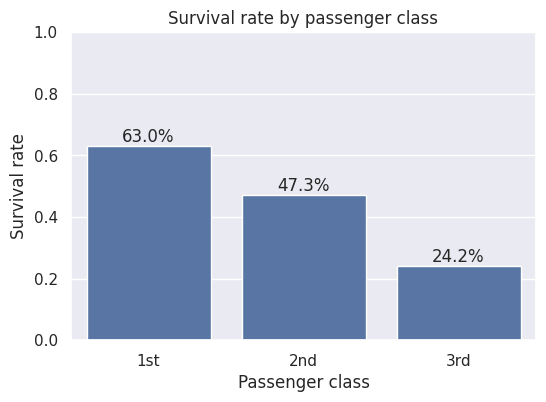

In [43]:
survival_by_class = (
    df_train
    .groupby("Pclass")["Survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=survival_by_class,
    x="Pclass",
    y="Survived"
)

# Annotate bars with percentages
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Survival rate by passenger class")
plt.xlabel("Passenger class")
plt.ylabel("Survival rate")

plt.ylim(0, 1)
plt.xticks([0, 1, 2], ["1st", "2nd", "3rd"])

plt.show()

The figure above reveals a clear relationship between passenger class and survival. First-class passengers had the highest survival rate, followed by those traveling in second class, while third-class passengers experienced the lowest survival rate by a considerable margin.

This pattern suggests that socioeconomic factors played an important role during the evacuation. Passengers in higher classes likely had cabins located closer to the boat deck, better access to information, or greater opportunity to board lifeboats before they reached capacity.

From a machine learning perspective, `Pclass` appears to be one of the strongest predictors of survival. It should therefore be retained as an important feature in our classification models.


### `Fare`

The `Fare` feature represents the price paid for a passenger's ticket. Since ticket prices were generally associated with passenger class and cabin location, they may also be indirectly related to survival. We explore this relationship by comparing the fare distributions of survivors and non-survivors.

Since `Fare` is a continuous variable with a highly skewed distribution, a box plot provides a convenient way to compare the fares paid by survivors and non-survivors. This visualization summarizes the distribution of each group while highlighting differences in their typical fare values and the presence of high-value outliers.

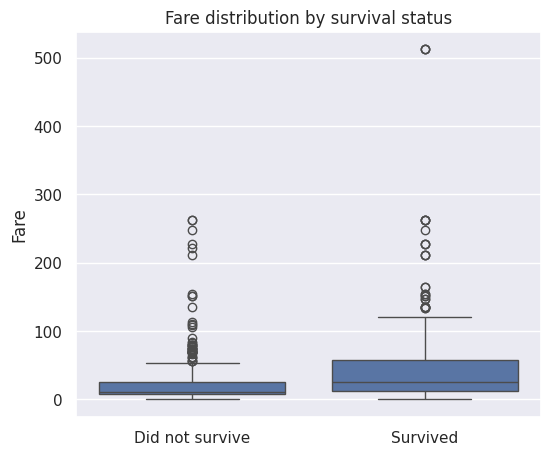

In [44]:
plt.figure(figsize=(6, 5))

sns.boxplot(
    data=df_train,
    x="Survived",
    y="Fare"
)

plt.xticks([0, 1], ["Did not survive", "Survived"])
plt.title("Fare distribution by survival status")
plt.xlabel("")
plt.ylabel("Fare")

plt.show()

The box plot shows that passengers who survived generally paid higher fares than those who did not. Although the two distributions overlap considerably, the median fare is noticeably higher among survivors, and a larger proportion of high-fare passengers survived.

This relationship is not surprising, as ticket fare is strongly associated with passenger class. Higher fares were typically paid by first-class passengers, who also exhibited substantially higher survival rates. Consequently, `Fare` is likely to provide useful predictive information, either on its own or in combination with related features such as `Pclass`.

### `Embarked`

Passengers boarded the Titanic at one of three ports: Cherbourg (`C`), Queenstown (`Q`), or Southampton (`S`). Differences in passenger demographics across these ports may have influenced survival rates. We therefore compare the proportion of survivors for each port of embarkation.

As with the other categorical features, we compare the survival rate for each port of embarkation rather than the raw passenger counts. This allows us to evaluate whether passengers embarking from different ports experienced different probabilities of survival.

/tmp/ipykernel_46974/1669966914.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Cherbourg", "Queenstown", "Southampton"])


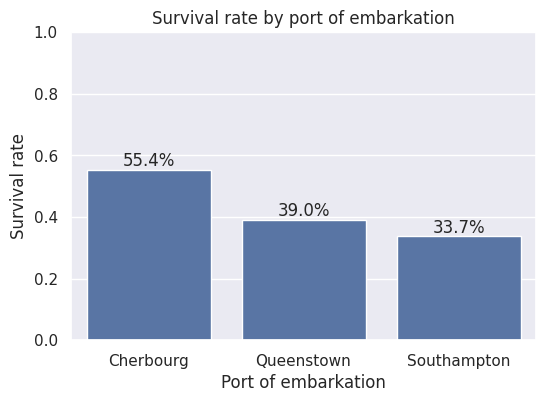

In [45]:
survival_by_embarked = (
    df_train
    .groupby("Embarked")["Survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=survival_by_embarked,
    x="Embarked",
    y="Survived",
    order=["C", "Q", "S"]
)

# Annotate bars with percentages
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

ax.set_xticklabels(["Cherbourg", "Queenstown", "Southampton"])

plt.title("Survival rate by port of embarkation")
plt.xlabel("Port of embarkation")
plt.ylabel("Survival rate")
plt.ylim(0, 1)

plt.show()

The figure above shows that survival rates varied across the three ports of embarkation. Passengers embarking at Cherbourg exhibited the highest survival rate, while those embarking at Southampton had the lowest. Queenstown fell between the two, although it is represented by a much smaller number of passengers.

These differences are unlikely to be caused by the embarkation port itself. Instead, they may reflect differences in the characteristics of the passengers boarding at each location. One possible explanation is that the three ports served different proportions of first-, second-, and third-class passengers, which we have already seen to be strongly associated with survival.

To investigate this hypothesis, we examine the composition of passenger classes at each port of embarkation. If one port has a substantially larger proportion of first-class passengers, for example, this could naturally lead to a higher overall survival rate.

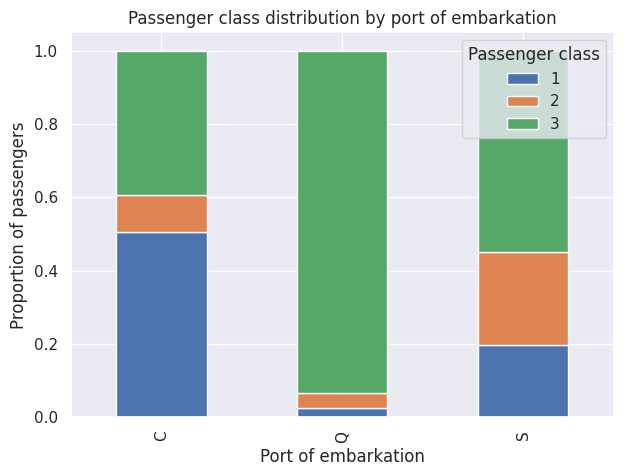

In [46]:
(
    pd.crosstab(
        df_train["Embarked"],
        df_train["Pclass"],
        normalize="index"
    )
    .plot(kind="bar", stacked=True, figsize=(7, 5))
)

plt.title("Passenger class distribution by port of embarkation")
plt.xlabel("Port of embarkation")
plt.ylabel("Proportion of passengers")
plt.legend(title="Passenger class")

plt.show()

The stacked bar chart supports this hypothesis. Cherbourg had a substantially larger proportion of first-class passengers, whereas Southampton was dominated by third-class passengers. Since we have already seen that passenger class is strongly associated with survival, much of the apparent effect of `Embarked` can be explained by its relationship with `Pclass`.

Although `Embarked` is therefore not an independent explanation for survival, it still carries useful predictive information because it captures differences in the composition of the passenger population. Machine learning models can exploit this information, even when it is correlated with other features.

### `SibSp`

The `SibSp` feature records the number of siblings and spouses traveling with each passenger. Traveling with family members may have influenced evacuation decisions and survival outcomes. In this section, we investigate whether the number of accompanying siblings or spouses is associated with survival.

To explore this relationship, we compute the survival rate for each value of `SibSp`. This allows us to examine whether traveling alone or with different numbers of siblings or spouses was associated with a higher or lower probability of survival.

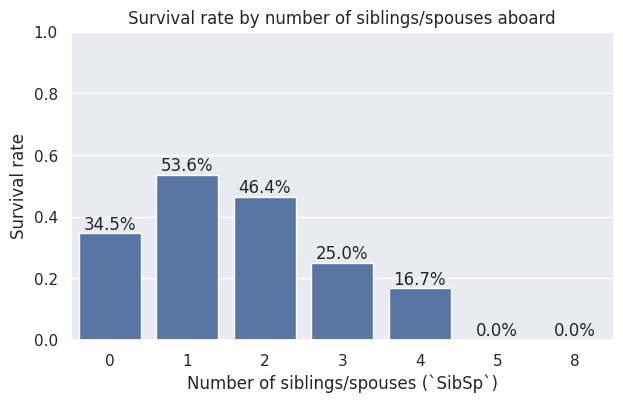

In [47]:
survival_by_sibsp = (
    df_train
    .groupby("SibSp")["Survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=survival_by_sibsp,
    x="SibSp",
    y="Survived"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Survival rate by number of siblings/spouses aboard")
plt.xlabel("Number of siblings/spouses (`SibSp`)")
plt.ylabel("Survival rate")
plt.ylim(0, 1)

plt.show()

The relationship between `SibSp` and survival is more complex than those observed for `Sex` or `Pclass`. Passengers traveling with one or two siblings or spouses generally exhibited higher survival rates than those traveling alone. However, survival rates declined for passengers traveling with larger numbers of family members.

This pattern suggests that the presence of family members may have been beneficial up to a point, while very large family groups may have faced additional challenges during the evacuation. Rather than the exact value of `SibSp` being important, the results hint that the overall family context may be more informative. This observation motivates the creation of derived features, such as total family size, in the next stage of the project.

### `Parch`

The `Parch` feature indicates the number of parents and children traveling with each passenger. Similar to `SibSp`, it provides information about family relationships aboard the Titanic. We examine whether traveling with parents or children is associated with differences in survival rates.

To analyze this relationship, we compute the survival rate for each value of `Parch`. This allows us to assess whether traveling with parents or children was associated with differences in the probability of survival.

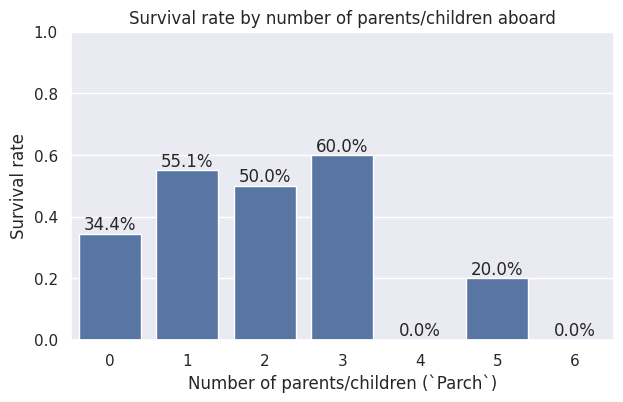

In [48]:
survival_by_parch = (
    df_train
    .groupby("Parch")["Survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=survival_by_parch,
    x="Parch",
    y="Survived"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Survival rate by number of parents/children aboard")
plt.xlabel("Number of parents/children (`Parch`)")
plt.ylabel("Survival rate")
plt.ylim(0, 1)

plt.show()

The relationship between `Parch` and survival shows a pattern similar to that observed for `SibSp`. Passengers traveling with one or two parents or children tend to exhibit higher survival rates than those traveling alone. However, survival rates decrease for passengers traveling with larger family groups.

These results suggest that moderate family presence may have been beneficial during the evacuation, while larger family groups may have faced additional coordination difficulties. Taken together with `SibSp`, this supports the idea that family structure is an important factor, but that it is not fully captured by either feature individually. This motivates the creation of a combined feature representing total family size.

### `Ticket`

The `Ticket` feature contains the passenger's ticket number. Although it appears to be an identifier, ticket numbers may encode information about booking groups or travel arrangements. We perform a brief inspection to determine whether this feature contains useful predictive information in its raw form.

To better understand this feature, we first inspect the distribution of ticket values. In particular, we check whether there are repeated ticket numbers or recognizable patterns that might indicate group bookings or shared travel arrangements.

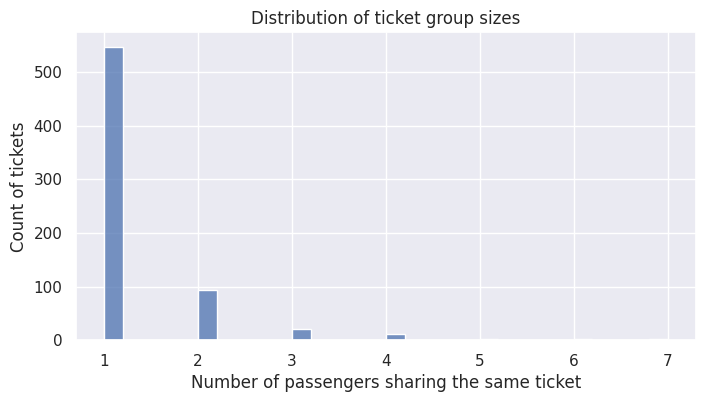

In [49]:
ticket_counts = df_train["Ticket"].value_counts()

#ticket_counts.head(10)

plt.figure(figsize=(8, 4))

sns.histplot(ticket_counts, bins=30)

plt.title("Distribution of ticket group sizes")
plt.xlabel("Number of passengers sharing the same ticket")
plt.ylabel("Count of tickets")

plt.show()

The inspection reveals that many ticket values are unique, while some tickets are shared by multiple passengers. This suggests that `Ticket` may encode partial information about group travel rather than functioning purely as an identifier.

However, the structure is not immediately interpretable in its raw form, and the feature has a very high cardinality with limited direct predictive signal. For this reason, we defer more detailed transformations of `Ticket` (such as extracting prefixes or grouping passengers by shared ticket numbers) to the feature engineering stage, where its potential structure can be explored more systematically.

### `Name`

At first glance, `Name` appears to be a simple identifier and therefore not directly useful for prediction. However, passenger names contain embedded structure, particularly honorific titles such as `Mr.`, `Mrs.`, `Miss`, and `Master`, which may reflect demographic and social characteristics associated with survival.

To investigate this, we extract and inspect the distribution of passenger titles.


In [50]:
df_train["Title"] = df_train["Name"].str.extract(r",\s*([^\.]+)\.", expand=False)

title_counts = df_train["Title"].value_counts()
title_counts.head(10)

Title
Mr        517
Miss      182
Mrs       125
Master     40
Dr          7
Rev         6
Col         2
Mlle        2
Major       2
Ms          1
Name: count, dtype: int64

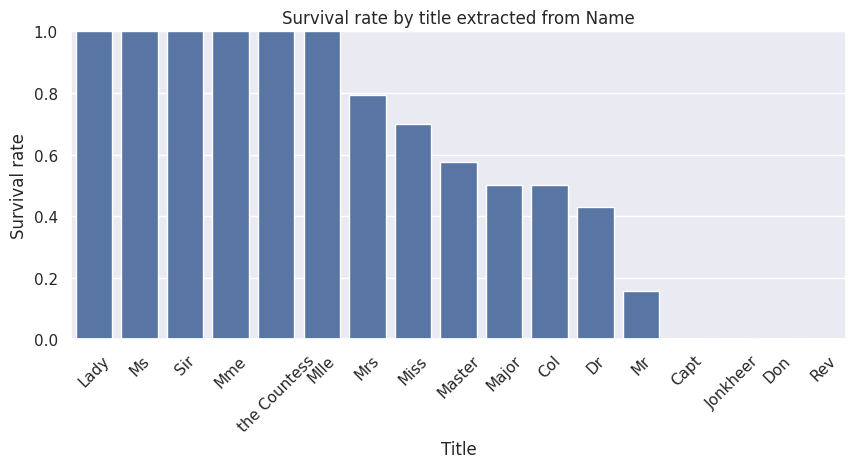

In [51]:
survival_by_title = (
    df_train
    .groupby("Title")["Survived"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 4))

ax = sns.barplot(
    data=survival_by_title,
    x="Title",
    y="Survived"
)

plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.title("Survival rate by title extracted from Name")
plt.xlabel("Title")
plt.ylabel("Survival rate")

plt.show()

Among the extracted titles, we also observe a small number of rare categories related to military or professional status, such as `Captain`.

In the Titanic dataset, the title `Captain` corresponds to Captain Edward Smith, the ship’s commanding officer, who did not survive the disaster. Although this is a single observation, it illustrates that some titles can carry meaningful contextual information, even when they appear only once in the dataset.

The results show clear differences in survival rates across passenger titles. Titles associated with women and children, such as `Mrs.`, `Miss`, and `Master`, tend to exhibit higher survival rates, while `Mr.` is associated with a substantially lower survival rate.

Less frequent titles also appear in the dataset and reflect variations in social status or roles on board. Although many of these categories contain very few observations, they may still encode useful information about passenger identity and context.

Overall, these findings confirm that `Name` contains structured and informative signals beyond simple identification. In particular, the extracted `Title` feature captures demographic and social information that is likely to improve predictive performance. For this reason, we will revisit `Name` during feature engineering to construct more informative variables.

### Summary of Findings

The exploratory analysis reveals several features that are strongly associated with passenger survival.

* `Sex` is the strongest individual predictor, with female passengers exhibiting substantially higher survival rates.
* `Pclass` is also highly informative, with first-class passengers surviving more frequently than those in second and third class.
* `Age` shows a weaker but noticeable relationship with survival, particularly for young children.
* `Fare` is positively associated with survival, although this relationship is partly explained by its correlation with `Pclass`.
* `Embarked` exhibits modest differences in survival rates across ports of embarkation, likely reflecting differences in passenger composition rather than the embarkation location itself.
* `SibSp` and `Parch` suggest that family structure may influence survival, motivating the creation of derived features such as `FamilySize` and `IsAlone`.
* `Name` contains structured information, particularly passenger titles, which show clear differences in survival rates across social and demographic groups. These patterns will be further exploited in the feature engineering stage through the creation of a dedicated `Title` feature.

These observations provide useful intuition about the dataset and directly inform the feature engineering choices made in the [next notebook](02_feature_engineering.ipynb).

## Save the processed dataset

At this stage, all identified data quality issues have been addressed, including the treatment of missing values and the removal or transformation of features that are not directly usable in their raw form. The dataset is now in a clean and consistent state.

To avoid repeating these preprocessing steps in subsequent notebooks, we save the processed data to disk. This ensures that the feature engineering and modeling stages operate on a stable and reproducible input.

The following notebook will build upon this dataset to perform feature engineering, including the creation of derived variables such as `Title`, `FamilySize`, and other transformations motivated by the exploratory analysis.

In [52]:
# Save dataframes in parquet format to preserve data types
df_full.to_parquet(
    "processed_data/01_data.parquet",
    index=False
)
df_features.to_parquet(
    "processed_data/01_features.parquet",
    index=False
)

## Closing Remarks

In this exploratory analysis, we examined the structure of the Titanic dataset, handled missing values, and investigated how individual features relate to passenger survival.

The analysis revealed several strong signals, particularly in `Sex`, `Pclass`, and `Age`, as well as more subtle patterns in features such as `Fare`, `Embarked`, and family-related variables (`SibSp`, `Parch`). In addition, we identified that both `Name` and `Ticket` contain structured information that is not directly usable in their raw form but may be transformed into more informative features.

These observations provide the foundation for the next stage of the project.

In the [following notebook](02_feature_engineering.ipynb), we will focus on feature engineering. This includes encoding categorical variables, extracting information from `Name` (such as passenger titles), creating family-based features, and transforming the dataset into a format suitable for machine learning models.
